<a href="https://colab.research.google.com/github/IdoiaUrra-TFG/TFG---SVMs-con-Kernels-Ortogonales-Un-Estudio-de-Sensibilidad-por-Grado/blob/main/Kernel_de_Chebyshev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

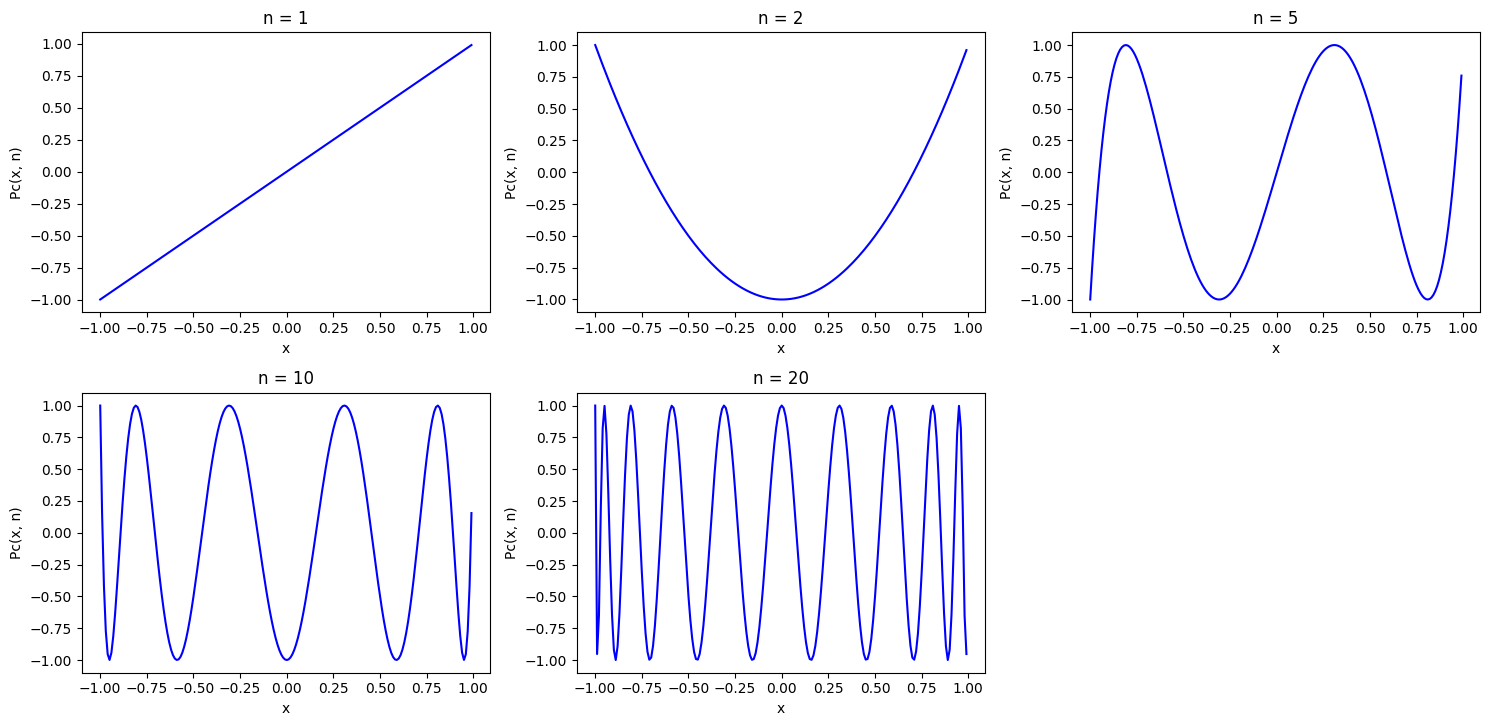

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# POLINOMIO DE CHEBYSHEV

def pc(x, n):
    if n == 0:
        return 1
    elif n == 1:
        return x
    else:
        pc_anteanterior = 1
        pc_anterior = x
        for i in range(1, n):
            pc_actual = 2 * x * pc_anterior - pc_anteanterior
            pc_anteanterior = pc_anterior
            pc_anterior = pc_actual
        return pc_actual

# Parámetros

n_vals = [1, 2, 5, 10, 20]
x = np.arange(-1, 1, 0.01)

# Panel 2×3 ─────────────────────────────────────────────────────

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
ax_plano = ax.flatten()

for i, n in enumerate(n_vals):
    eje = ax_plano[i]
    eje.plot(x, pc(x, n), color='blue')
    eje.set_title(f'n = {n}')
    eje.set_xlabel('x')
    eje.set_ylabel('Pc(x, n)')

fig.delaxes(ax_plano[5])
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("chebyshev_polinomios.png", dpi=150, bbox_inches="tight")
plt.show()

# Descarga

from google.colab import files
files.download("chebyshev_polinomios.png")

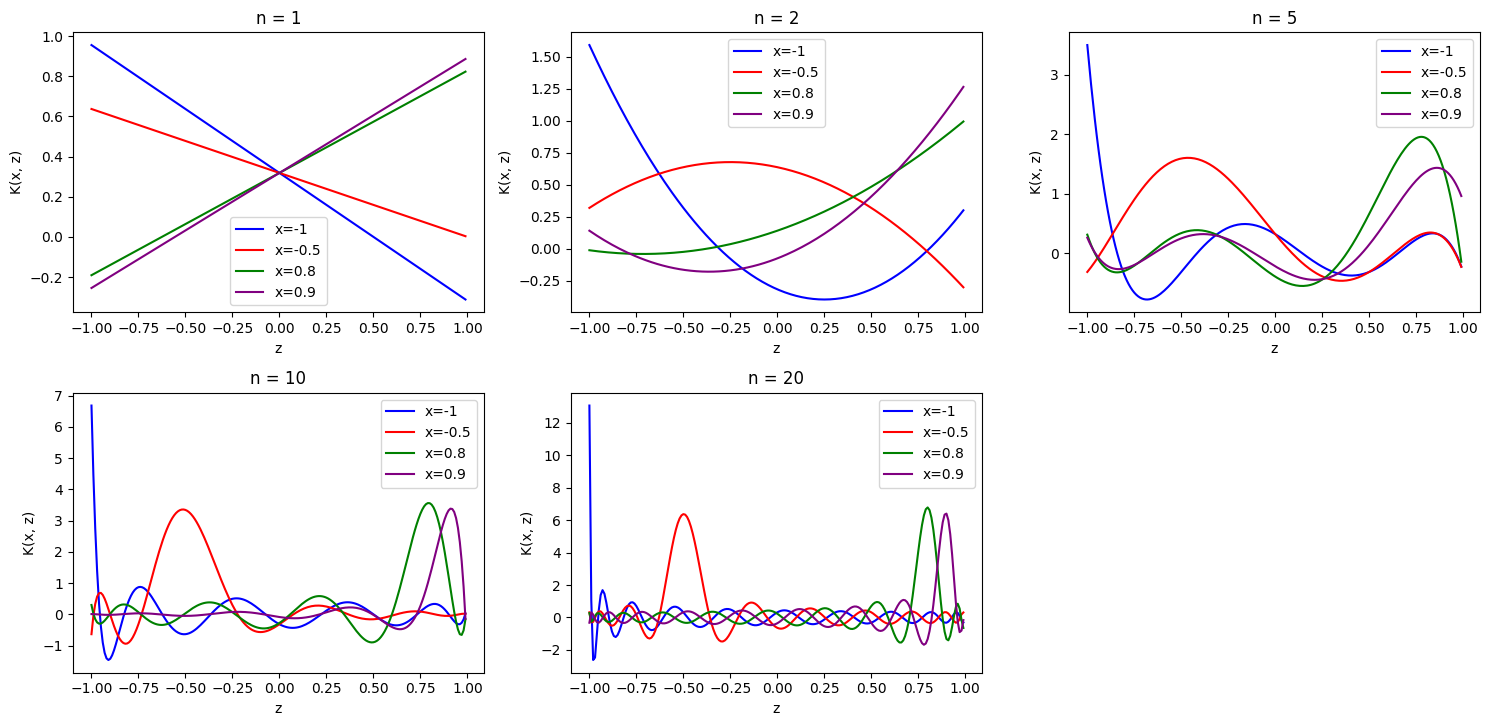

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
# KERNEL DE CHEBYSHEV

pi = np.pi

def kc(x, z, n):
    solkc = (1 / pi) * pc(x, 0) * pc(z, 0)
    for i in range(1, n + 1):
        solkc += (2 / pi) * pc(x, i) * pc(z, i)
    return solkc

# Parámetros

x0     = [-1, -0.5, 0.8, 0.9]
colores = ["blue", "red", "green", "purple"]
z      = np.arange(-1, 1, 0.01)

# Panel 2×3

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
ax_plano = ax.flatten()

for i, n in enumerate(n_vals):
    eje = ax_plano[i]
    for x_val, color in zip(x0, colores):
        eje.plot(z, kc(x_val, z, n), label=f"x={x_val}", color=color)
    eje.set_title(f"n = {n}")
    eje.set_xlabel("z")
    eje.set_ylabel("K(x, z)")
    eje.legend()

fig.delaxes(ax_plano[5])
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("kernel_chebyshev.png", dpi=150, bbox_inches="tight")
plt.show()

# Descarga

from google.colab import files
files.download("kernel_chebyshev.png")

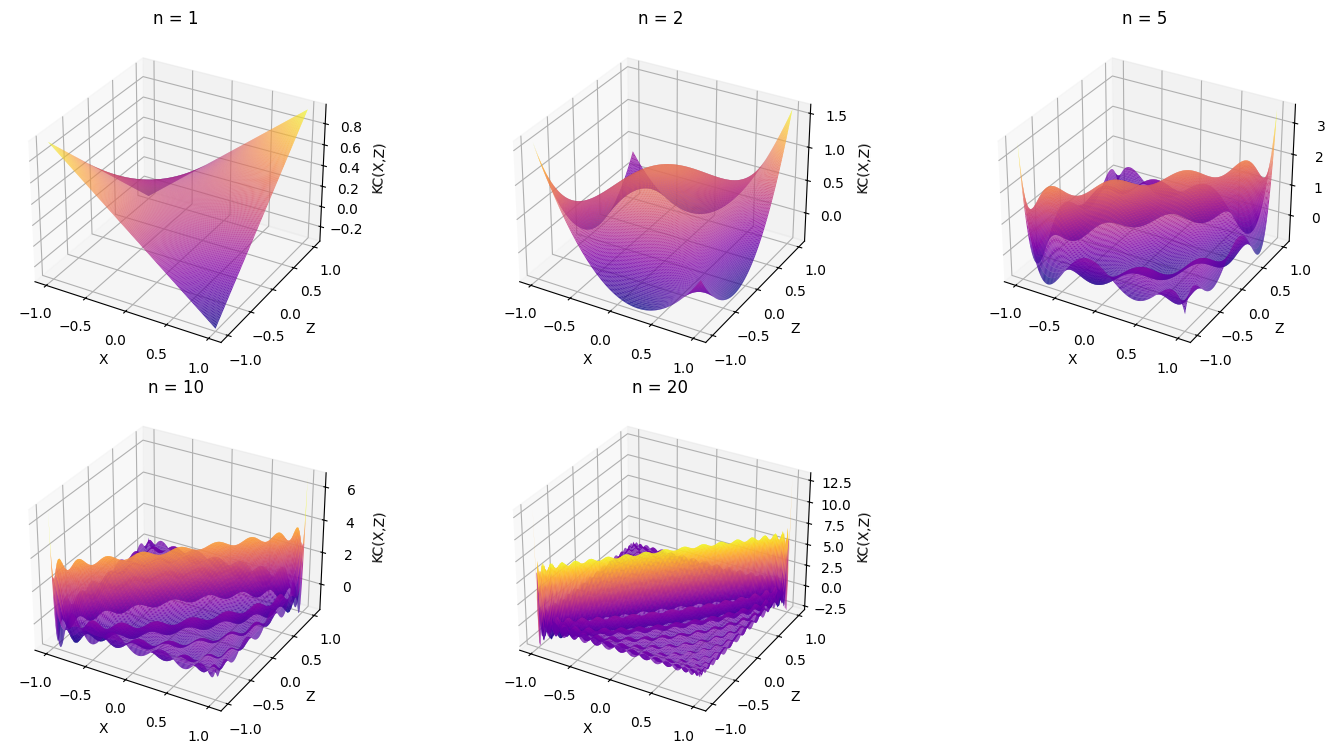

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
# Kernel en 3D

vectorized_kc = np.vectorize(kc)

# Rejilla
rango = np.arange(-1, 1.01, 0.01)
X, Z  = np.meshgrid(rango, rango)

# Panel 2×3 en 3D
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 8),
                       subplot_kw={'projection': '3d'})
ax_plano = ax.flatten()

for i in range(5):
    eje = ax_plano[i]
    kernel = vectorized_kc(X, Z, n_vals[i])
    eje.plot_surface(X, Z, kernel, cmap='plasma', rstride=1, cstride=1, alpha=0.9)
    eje.set_title(f'n = {n_vals[i]}')
    eje.set_xlabel('X')
    eje.set_ylabel('Z')
    eje.set_zlabel('KC(X,Z)')

fig.delaxes(ax_plano[5])
fig.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig("kernel_chebyshev_3D.png", dpi=150, bbox_inches="tight")
plt.show()

# Descarga

from google.colab import files
files.download("kernel_chebyshev_3D.png")

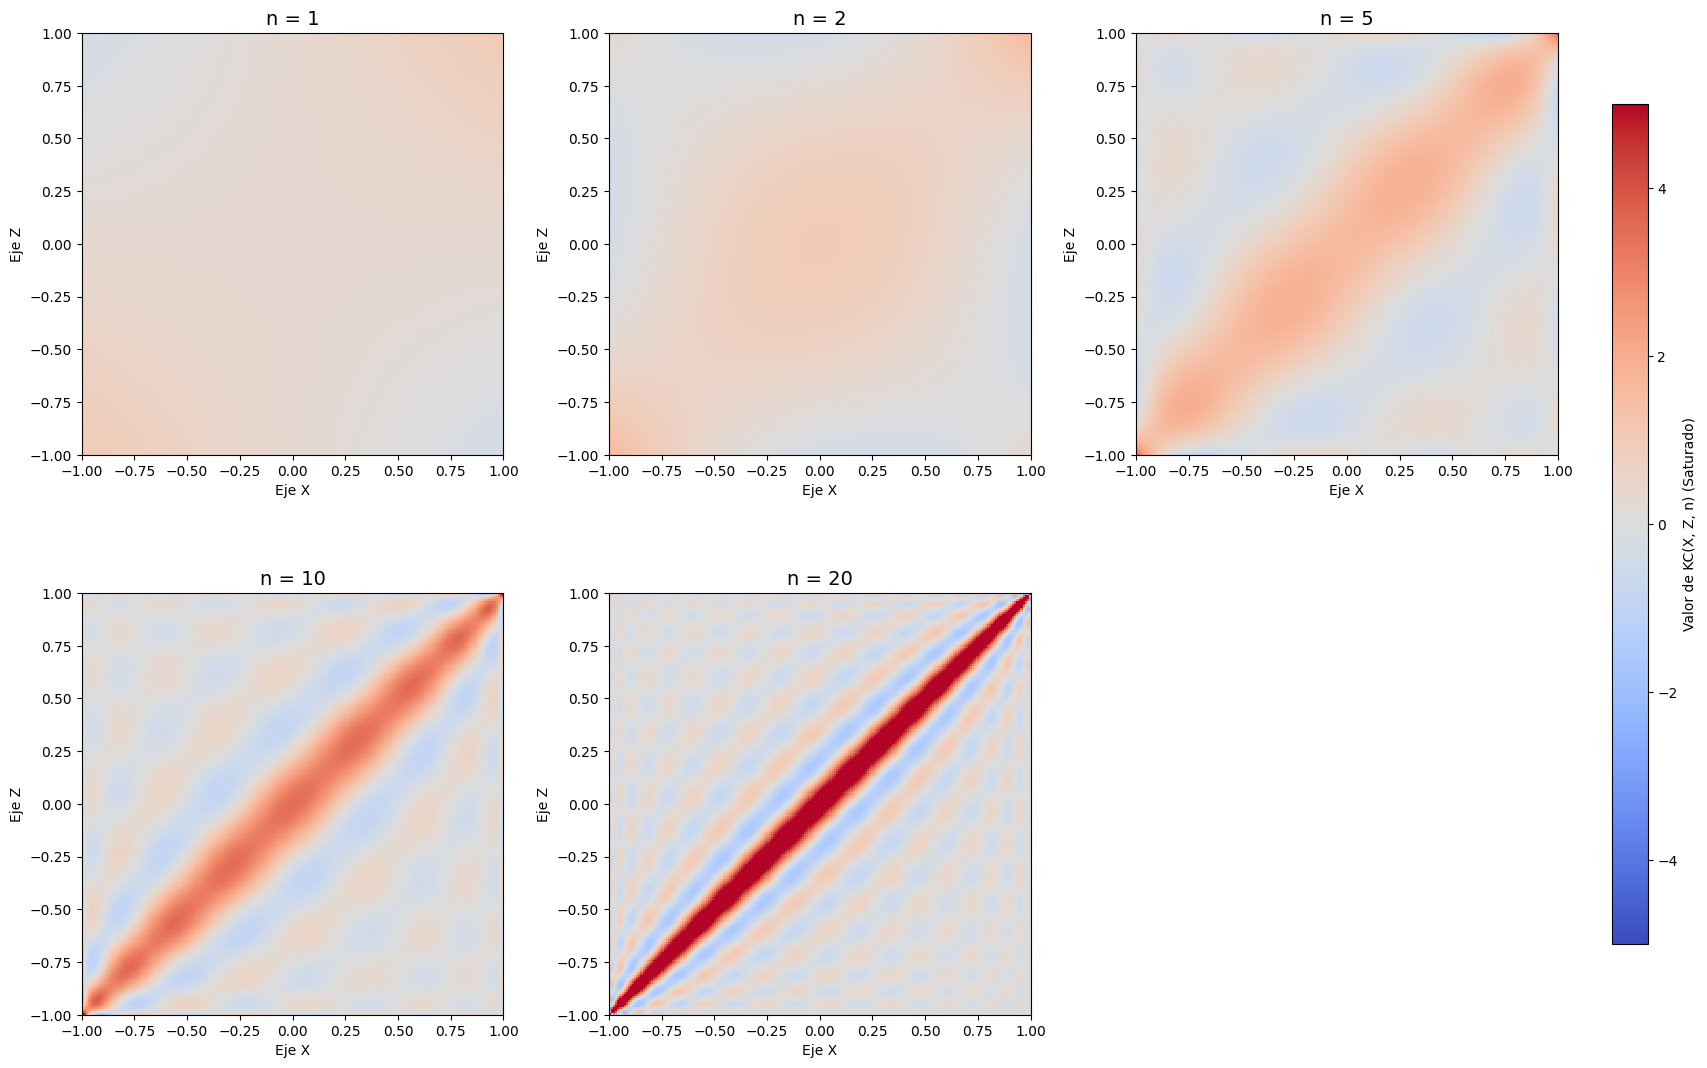

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
# Mapa calor
from matplotlib import colors
import matplotlib.pyplot as plt

Z_total = [vectorized_kc(X, Z, N) for N in n_vals]

COLOR_MIN = -5.0
COLOR_MAX =  5.0
norm_personalizada = colors.Normalize(vmin=COLOR_MIN, vmax=COLOR_MAX)

# Panel 2×3
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
ax_plano = ax.flatten()

for i, N in enumerate(n_vals):
    eje = ax_plano[i]
    im = eje.imshow(Z_total[i],
                    cmap='coolwarm',
                    interpolation='none',
                    extent=[rango_puntos.min(), rango_puntos.max(),
                            rango_puntos.min(), rango_puntos.max()],
                    origin='lower',
                    norm=norm_personalizada)
    eje.set_title(f'n = {N}', fontsize=14)
    eje.set_xlabel('Eje X')
    eje.set_ylabel('Eje Z')

fig.delaxes(ax_plano[5])

fig.subplots_adjust(left=0.06, bottom=0.08, right=0.88, top=0.92, hspace=0.25, wspace=0.25)

cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Valor de KC(X, Z, n) (Saturado)')

plt.savefig("calor_chebyshev.png", dpi=150, bbox_inches="tight")
plt.show()

# Descarga
from google.colab import files
files.download("calor_chebyshev.png")